In [3]:
!pip install pennylane
!pip install torchinfo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 58.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 69.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 62.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 100.8 MB/s eta 0:00:0000:0100:01


In [4]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import timedelta

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models

from sklearn.metrics import *
from tqdm.auto import tqdm

import pennylane as qml

In [5]:
IMG_SIZE = 224
BATCH_SIZE = 8
EPOCHS = 20
PATIENCE = 5
RANDOM_STATE = 42

torch.manual_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [6]:
CSV_PATH = "/kaggle/input/datasets/farjanakabirsamanta/skin-cancer-dataset/HAM10000_metadata.csv"

IMG_DIR = "/kaggle/input/datasets/farjanakabirsamanta/skin-cancer-dataset/Skin Cancer/Skin Cancer"

In [7]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [8]:
class SkinCancerDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

        self.classes = sorted(self.df['dx'].unique())
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.df['label'] = self.df['dx'].map(self.class_to_idx)

        self.image_paths = []
        self.labels = []

        for _, row in self.df.iterrows():
            img_name = row['image_id'] + ".jpg"
            img_path = os.path.join(self.img_dir, img_name)

            if os.path.exists(img_path):
                self.image_paths.append(img_path)
                self.labels.append(row['label'])

        print(f"✅ Total valid images found: {len(self.image_paths)}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [9]:
full_dataset = SkinCancerDataset(CSV_PATH, IMG_DIR, transform=transform)

CLASSES = full_dataset.classes
num_classes = len(CLASSES)

print("Classes:", CLASSES)

✅ Total valid images found: 10015
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [10]:
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

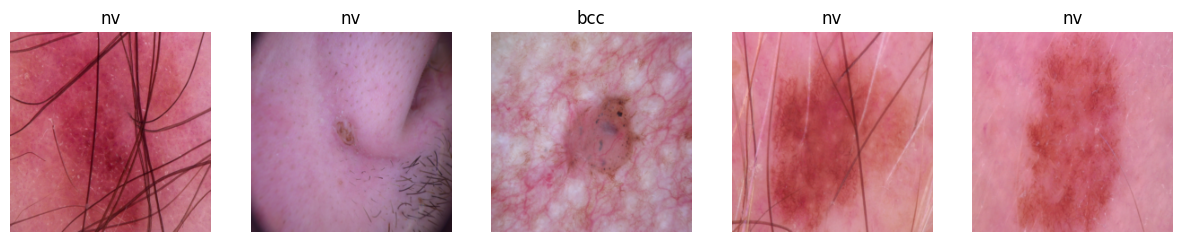

In [11]:
def show_random_images(loader):
    images, labels = next(iter(loader))
    fig, axs = plt.subplots(1, 5, figsize=(15,5))

    for i in range(5):
        axs[i].imshow(images[i].permute(1,2,0))
        axs[i].set_title(CLASSES[labels[i]])
        axs[i].axis("off")

    plt.show()

show_random_images(train_loader)

In [12]:
n_qubits = 8

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    # Encode
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)

    # Trainable rotations
    for i in range(n_qubits):
        qml.RZ(weights[i], wires=i)

    # Entanglement
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i+1])

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


class QuantumLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(n_qubits))

    def forward(self, x):
        outputs = []
        for i in range(x.shape[0]):
            out = quantum_circuit(x[i], self.weights)

            # 🔥 FIX: convert to tensor
            out = torch.stack(out)

            outputs.append(out)

        return torch.stack(outputs).float()

In [13]:
class HybridMobileNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        base = models.mobilenet_v2(weights="DEFAULT")
        self.features = base.features

        # 🔥 Quantum branch
        self.q_branch = nn.Sequential(
            nn.Conv2d(160, 40, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(40, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )

        self.q_fc = nn.Linear(8, n_qubits)
        self.quantum = QuantumLayer()

        # ✅ ONLY FINAL FC (correct design)
        self.final_fc = nn.Linear(1280 + n_qubits, num_classes)

    def forward(self, x):
        # Split point
        x = self.features[:17](x)

        # 🔵 Quantum branch
        q = self.q_branch(x)
        q = torch.flatten(q, 1)
        q = torch.tanh(self.q_fc(q))
        q = self.quantum(q)   # [batch, n_qubits]

        # 🔵 Classical branch
        c = self.features[17:](x)
        c = torch.nn.functional.adaptive_avg_pool2d(c, (1,1))
        c = torch.flatten(c, 1)   # [batch, 1280]

        # 🔗 CONCAT
        out = torch.cat([c, q], dim=1)   # [batch, 1280 + n_qubits]

        # 🔥 FINAL OUTPUT
        out = self.final_fc(out)

        return out

In [14]:
model = HybridMobileNet(num_classes).to(device)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 103MB/s] 


In [15]:
from torchinfo import summary
summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                             Output Shape              Param #
HybridMobileNet                                    [1, 7]                    --
├─Sequential: 1-5                                  --                        (recursive)
│    └─Conv2dNormActivation: 2-1                   [1, 32, 112, 112]         --
│    │    └─Conv2d: 3-1                            [1, 32, 112, 112]         864
│    │    └─BatchNorm2d: 3-2                       [1, 32, 112, 112]         64
│    │    └─ReLU6: 3-3                             [1, 32, 112, 112]         --
│    └─InvertedResidual: 2-2                       [1, 16, 112, 112]         --
│    │    └─Sequential: 3-4                        [1, 16, 112, 112]         896
│    └─InvertedResidual: 2-3                       [1, 24, 56, 56]           --
│    │    └─Sequential: 3-5                        [1, 24, 56, 56]           5,136
│    └─InvertedResidual: 2-4                       [1, 24, 56, 56]           --
│    │    └─Sequentia

In [16]:
!pip install torchviz graphviz
!pip install hiddenlayer

In [17]:
from graphviz import Digraph

dot = Digraph(format='svg')

# Input
dot.node('Input', 'Input Image\n(3×224×224)')

# Backbone
dot.node('MobileNet1', 'MobileNetV2\nFeatures (up to layer 17)\n[160×7×7]')
dot.edge('Input', 'MobileNet1')

# Split
dot.node('Split', 'Feature Split')
dot.edge('MobileNet1', 'Split')

# =========================
# Classical Branch
# =========================
dot.node('Classical1', 'Remaining MobileNet\nLayers')
dot.node('Classical2', 'Global Avg Pool\n→ Flatten (1280)')

dot.edge('Split', 'Classical1')
dot.edge('Classical1', 'Classical2')

# =========================
# Quantum Branch
# =========================
dot.node('Q1', '1×1 Conv\n(160→40)')
dot.node('Q2', '3×3 Conv\n(40→8)')
dot.node('Q3', 'Adaptive Pool\n(1×1)')
dot.node('Q4', 'Flatten (8)')
dot.node('Q5', 'Quantum Layer\n(8 qubits)')

dot.edge('Split', 'Q1')
dot.edge('Q1', 'Q2')
dot.edge('Q2', 'Q3')
dot.edge('Q3', 'Q4')
dot.edge('Q4', 'Q5')

# =========================
# Fusion + FINAL FC (ONLY ONE)
# =========================
dot.node('Fusion', 'Concatenate\n(1280 + 8)')
dot.node('Output', 'Final FC Layer\n(7 classes)')

dot.edge('Classical2', 'Fusion')
dot.edge('Q5', 'Fusion')
dot.edge('Fusion', 'Output')

# Save
dot.render('hybrid_mobilenet_quantum_corrected', cleanup=True)

print("✅ Corrected SVG generated!")

✅ Corrected SVG generated!


In [18]:
from torchviz import make_dot
import torch

# Create dummy input
x = torch.randn(1, 3, 224, 224).to(device)

# Forward pass
y = model(x)

# Generate graph
dot = make_dot(y, params=dict(model.named_parameters()))

# Save as SVG
dot.format = 'svg'
dot.render('hybrid_mobilenet_quantum_architecture', cleanup=True)

print("✅ SVG saved as hybrid_mobilenet_quantum_architecture.svg")

✅ SVG saved as hybrid_mobilenet_quantum_architecture.svg


In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [20]:
def custom_metrics(y_pred, y_true, loss):
    y_pred_classes = torch.argmax(y_pred, dim=1)

    y_true = y_true.cpu().numpy()
    y_pred = y_pred_classes.cpu().numpy()

    return {
        "loss": loss,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "recall": recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "f1_score": f1_score(y_true, y_pred, average='weighted', zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred)
    }

In [21]:
train_hist = {"loss":[], "accuracy":[]}
val_hist = {"loss":[], "accuracy":[]}

best_val_loss = float("inf")
patience_counter = 0

for epoch in range(EPOCHS):
    start_time = time.time()
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    model.train()
    train_loss = 0
    all_preds, all_labels = [], []

    for x, y in tqdm(train_loader, desc="Training"):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        all_preds.append(out)
        all_labels.append(y)

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    train_metrics = custom_metrics(all_preds, all_labels, train_loss/len(train_loader))
    print("Train:", train_metrics)

    train_hist["loss"].append(train_metrics["loss"])
    train_hist["accuracy"].append(train_metrics["accuracy"])

    # Validation
    model.eval()
    val_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in tqdm(val_loader, desc="Validation"):
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            val_loss += loss.item()
            all_preds.append(out)
            all_labels.append(y)

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    val_metrics = custom_metrics(all_preds, all_labels, val_loss/len(val_loader))
    print("Val:", val_metrics)

    val_hist["loss"].append(val_metrics["loss"])
    val_hist["accuracy"].append(val_metrics["accuracy"])

    print("Epoch Time:", str(timedelta(seconds=int(time.time() - start_time))))

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ Model Saved")
    else:
        patience_counter += 1
        print(f"⚠️ No improvement ({patience_counter}/{PATIENCE})")

        if patience_counter >= PATIENCE:
            print("⛔ Early Stopping Triggered")
            break


Epoch 1/20


Training:   0%|          | 0/877 [00:00<?, ?it/s]

Train: {'loss': 0.7885363021591506, 'accuracy': 0.7248216833095578, 'precision': 0.6801904043251237, 'recall': 0.7248216833095578, 'f1_score': 0.6864663069150662, 'mcc': np.float64(0.4053678223949929)}


Validation:   0%|          | 0/188 [00:00<?, ?it/s]

Val: {'loss': 0.5303632609764154, 'accuracy': 0.7982689747003995, 'precision': 0.7966267468955719, 'recall': 0.7982689747003995, 'f1_score': 0.7895896378965184, 'mcc': np.float64(0.5898391446039247)}
Epoch Time: 0:08:01
✅ Model Saved

Epoch 2/20


...

Val: {'loss': 0.5184968956628507, 'accuracy': 0.8395472703062583, 'precision': 0.8355305435274992, 'recall': 0.8395472703062583, 'f1_score': 0.8347330065370074, 'mcc': np.float64(0.6730476039675097)}
Epoch Time: 0:06:10
⚠️ No improvement (4/5)

Epoch 7/20


Training:   0%|          | 0/877 [00:00<?, ?it/s]

Train: {'loss': 0.11615387919308998, 'accuracy': 0.9594864479315264, 'precision': 0.9592953397122803, 'recall': 0.9594864479315264, 'f1_score': 0.9593127989734501, 'mcc': np.float64(0.922701330822111)}


Validation:   0%|          | 0/188 [00:00<?, ?it/s]

Val: {'loss': 0.6580769107033043, 'accuracy': 0.8268974700399467, 'precision': 0.8161122344728942, 'recall': 0.8268974700399467, 'f1_score': 0.8168851198454142, 'mcc': np.float64(0.6389967412434245)}
Epoch Time: 0:06:10
⚠️ No improvement (5/5)
⛔ Early Stopping Triggered


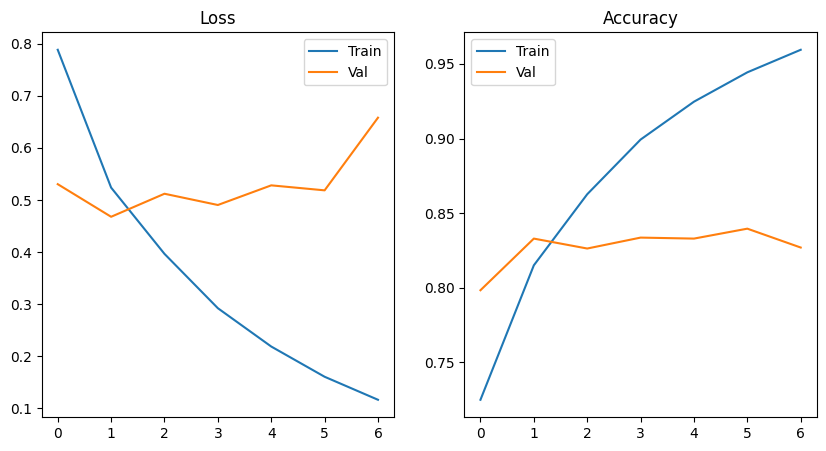

In [22]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(train_hist["loss"], label="Train")
plt.plot(val_hist["loss"], label="Val")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(train_hist["accuracy"], label="Train")
plt.plot(val_hist["accuracy"], label="Val")
plt.legend()
plt.title("Accuracy")

plt.show()

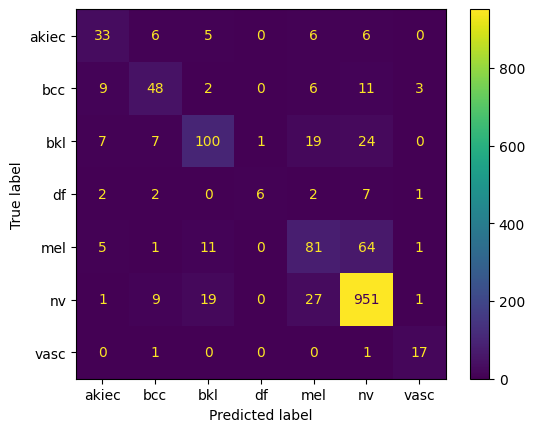

              precision    recall  f1-score   support

       akiec       0.58      0.59      0.58        56
         bcc       0.65      0.61      0.63        79
         bkl       0.73      0.63      0.68       158
          df       0.86      0.30      0.44        20
         mel       0.57      0.50      0.53       163
          nv       0.89      0.94      0.92      1008
        vasc       0.74      0.89      0.81        19

    accuracy                           0.82      1503
   macro avg       0.72      0.64      0.66      1503
weighted avg       0.81      0.82      0.82      1503



In [23]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)

        all_preds.append(out)
        all_labels.append(y)

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

pred_classes = torch.argmax(all_preds, dim=1)

cm = confusion_matrix(all_labels.cpu(), pred_classes.cpu())
disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
disp.plot()
plt.show()

print(classification_report(all_labels.cpu(), pred_classes.cpu(), target_names=CLASSES))